# EDA · técnicas del máster aplicadas a una serie temporal

`FuncionesMineria.py` es la caja de herramientas de la asignatura de minería de datos, y se usó
en la tarea de elecciones. Antes de reaprovecharla aquí conviene separar dos cosas: **qué
transfiere a un problema de serie temporal con target continuo** y qué no.

La respuesta corta es que tres funciones aportan algo que los notebooks 02-05 no tienen, y al
menos cuatro producirían resultados incorrectos si se aplicaran tal cual. El bloque D de este
notebook documenta las segundas — y eso es material de memoria, no una nota interna: explicar
*por qué* una técnica estándar no aplica demuestra más criterio que aplicarla.

## Índice

| Bloque | Contenido | Origen |
|---|---|---|
| **A** | Patrón de valores ausentes: ¿los huecos van juntos? | `patron_perdidos` |
| **B** | V de Cramér frente a correlación de Pearson | `Vcramer`, `graficoVcramer` |
| **C** | Distribución del driver por tramo del target | `boxplot_targetbinaria` adaptado |
| **D** | Las que NO se pueden usar, y por qué | varias |

---
## 0 · Carga

In [23]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

%matplotlib inline
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

TZ = "Europe/Madrid"
RAIZ = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
BRONZE_DIR = RAIZ / "data" / "bronze"

plt.rcParams.update({"figure.figsize": (10, 4), "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})

df = pd.read_parquet(BRONZE_DIR / "bronze_unificado.parquet")
df["ts_utc"] = pd.to_datetime(df["ts_utc"], utc=True)
assert df["ts_utc"].duplicated().sum() == 0, "parquet duplicado: regenerar antes de seguir"

df["ts_local"] = df["ts_utc"].dt.tz_convert(TZ)
df["hora"] = df["ts_local"].dt.hour
df["anio"] = df["ts_local"].dt.year
print(f"{len(df):,} horas x {df.shape[1]} columnas")

def pick(d, *c):
    for x in c:
        if x is not None and x in d.columns:
            return x
    return None

# Target: si spot_price ya está en el bronce se usa; si no, se toma la demanda como
# variable de referencia para poder ilustrar las técnicas igualmente.
TARGET = pick(df, "spot_es_omie", "es_omie", "spot_es_esios")
if TARGET is None:
    TARGET = pick(df, "load_inter_entsoe_load")
    print(f"\nspot_price no está en el bronce: se usa '{TARGET}' como variable de referencia.")
    print("Las técnicas se ilustran igual, pero las conclusiones sobre el PRECIO habrá que")
    print("rehacerlas cuando spot_price entre al bronce.")
else:
    print(f"\nTarget: {TARGET}")

58,319 horas x 99 columnas

Target: spot_es_omie


---
## A · Patrón de valores ausentes

**Qué hace la función original.** `patron_perdidos` calcula la matriz de correlación de la
*indicadora de ausencia* de cada columna y la pinta como mapa de calor. Dos columnas con
correlación 1 en esa matriz faltan siempre a la vez.

**Por qué aporta aquí, y por qué el bloque B del notebook 02 no lo cubre.** Aquel bloque cuenta
*cuántos* nulos hay por columna; éste dice *si van juntos*. Es la diferencia entre saber que
ERA5 tiene un 67 % de nulos y demostrar que ese 67 % es **el mismo patrón en las nueve
variables** — o sea, estructural, del merge trihorario — mientras que la ráfaga tiene además una
parte independiente del resto.

Es la prueba formal de lo que en el 02 se afirmaba por inspección visual.

70 columnas con al menos un nulo


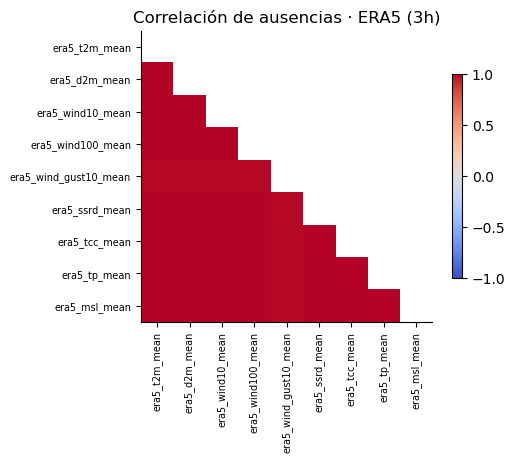

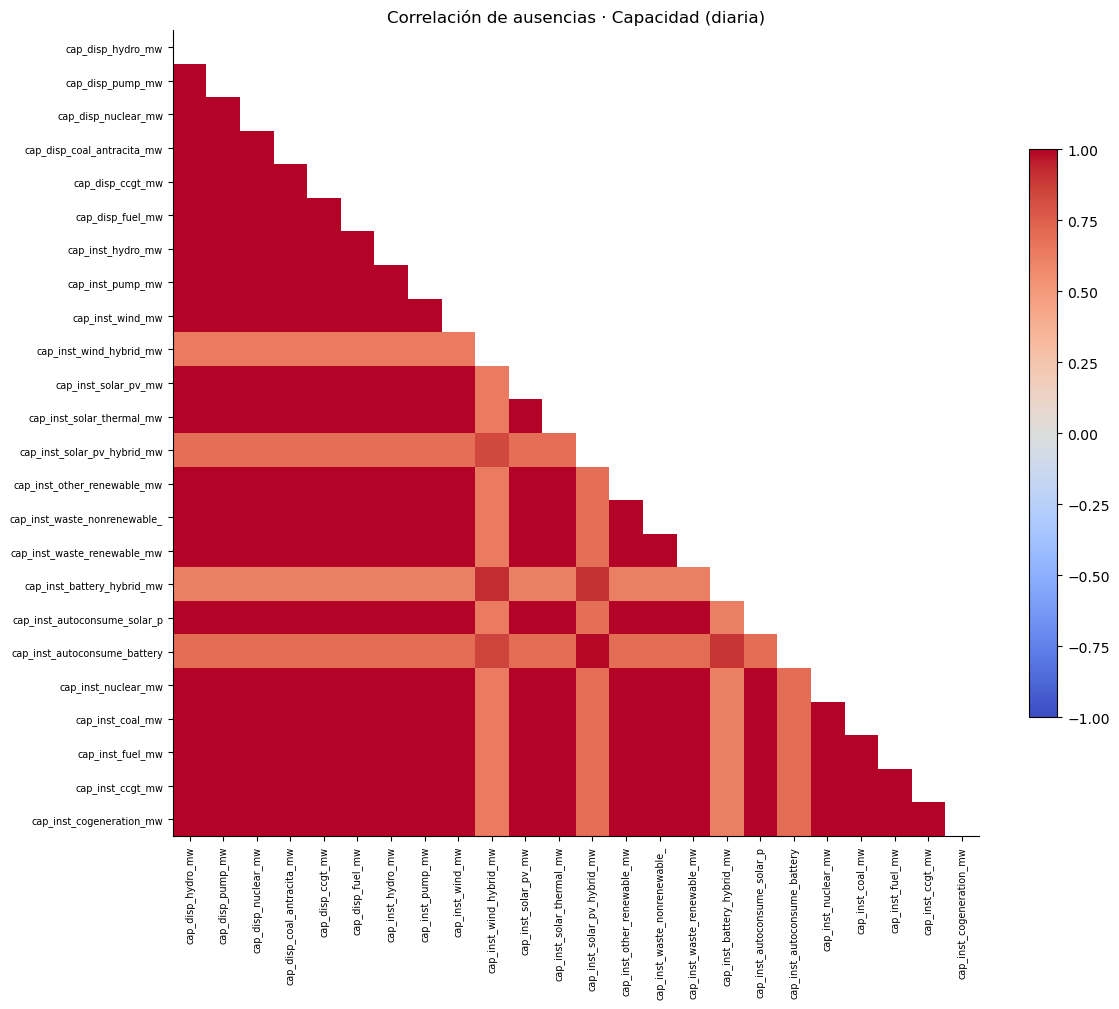

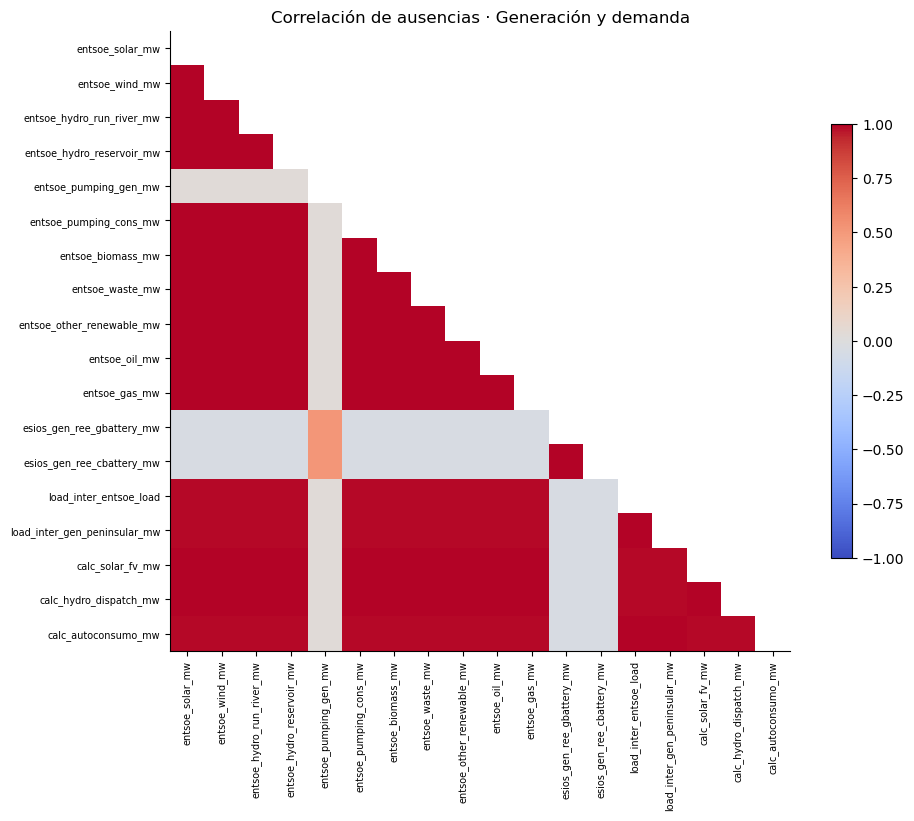

In [24]:
con_nulos = df.columns[df.isna().sum() > 0]
print(f"{len(con_nulos)} columnas con al menos un nulo")

# Agrupadas por familia, que si no el mapa es ilegible con 40 columnas.
FAMILIAS = {
    "ERA5 (3h)": [c for c in con_nulos if c.startswith("era5_")],
    "Capacidad (diaria)": [c for c in con_nulos if c.startswith(("cap_inst_", "cap_disp_"))],
    "Generación y demanda": [c for c in con_nulos
                             if c.startswith(("entsoe_", "esios_gen_", "load_inter_", "calc_"))],
}
for nombre, cols in FAMILIAS.items():
    if len(cols) < 2:
        continue
    m = df[cols].isna().corr()
    fig, ax = plt.subplots(figsize=(min(1 + 0.5 * len(cols), 12), min(1 + 0.4 * len(cols), 10)))
    mask = np.triu(np.ones_like(m, dtype=bool))
    im = ax.imshow(np.where(mask, np.nan, m.values), cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(cols)), [c[:28] for c in cols], rotation=90, fontsize=7)
    ax.set_yticks(range(len(cols)), [c[:28] for c in cols], fontsize=7)
    ax.set_title(f"Correlación de ausencias · {nombre}"); ax.grid(False)
    fig.colorbar(im, ax=ax, shrink=0.7)
    plt.tight_layout(); plt.show()

In [25]:
# Lectura numérica: pares que SIEMPRE faltan juntos, y columnas con ausencia propia.
todas = list(con_nulos)
M = df[todas].isna().corr()

perfectos = []
for i, a in enumerate(todas):
    for b in todas[i + 1:]:
        r = M.loc[a, b]
        if pd.notna(r) and r > 0.999:
            perfectos.append((a, b, round(r, 4)))
print(f"Pares que faltan SIEMPRE a la vez (r > 0,999): {len(perfectos)}")
for a, b, r in perfectos[:12]:
    print(f"  {a[:34]:34s} <-> {b[:34]:34s} {r}")
if len(perfectos) > 12:
    print(f"  ... y {len(perfectos)-12} más")

# La columna con la ausencia MENOS explicada por las demás es la que tiene hueco propio.
independencia = M.abs().apply(lambda s: s.drop(s.name).max()).sort_values()
print("\nColumnas cuya ausencia menos coincide con la de otras (hueco propio):")
display(independencia.head(8).round(4).rename("máx. correlación con otra").to_frame())

Pares que faltan SIEMPRE a la vez (r > 0,999): 354
  entsoe_solar_mw                    <-> entsoe_wind_mw                     1.0
  entsoe_solar_mw                    <-> entsoe_hydro_run_river_mw          1.0
  entsoe_solar_mw                    <-> entsoe_hydro_reservoir_mw          1.0
  entsoe_solar_mw                    <-> entsoe_pumping_cons_mw             1.0
  entsoe_solar_mw                    <-> entsoe_biomass_mw                  1.0
  entsoe_solar_mw                    <-> entsoe_waste_mw                    1.0
  entsoe_solar_mw                    <-> entsoe_other_renewable_mw          1.0
  entsoe_solar_mw                    <-> entsoe_oil_mw                      1.0
  entsoe_solar_mw                    <-> entsoe_gas_mw                      1.0
  entsoe_solar_mw                    <-> calc_solar_fv_mw                   1.0
  entsoe_solar_mw                    <-> calc_hydro_dispatch_mw             1.0
  entsoe_wind_mw                     <-> entsoe_hydro_run_river_mw   

,máx. correlación con otra
spot_it_nord_entsoe,0.4751
entsoe_pumping_gen_mw,0.5123
forecast_demanda_residual_prev_mw,0.8451
cap_inst_wind_hybrid_mw,0.9216
cap_inst_battery_hybrid_mw,0.9216
forecast_demanda_mercado_prev_mw,0.9258
spot_es_esios,0.9258
cap_inst_autoconsume_battery_mw,0.9869


**Consecuencia.** Un bloque de correlación 1 entre las nueve variables de ERA5 confirma que su
ausencia es **una sola causa** (el paso trihorario) y no nueve problemas. Y si
`era5_wind_gust10_mean` aparece con correlación algo menor que el resto, ahí está la firma
numérica del hueco propio de junio-2026 que el notebook 02 identificó por otra vía.

Lo mismo con las tablas diarias: si todas las `cap_inst_*` y `commodities_*` forman un bloque
perfecto, su 95,8 % es el mismo 23/24 y no hay nada que investigar.

---
## B · V de Cramér frente a correlación de Pearson

**Qué hace la función original.** `Vcramer` discretiza ambas variables en quintiles, construye
la tabla de contingencia y calcula el V de Cramér a partir del chi-cuadrado. Mide **asociación
de cualquier forma**, no sólo lineal.

**Por qué importa aquí más que en la tarea de elecciones.** El bloque G del notebook 03 ordena
los drivers por correlación de Pearson, que sólo ve relaciones lineales. Y ya sabemos que al
menos una relación clave del sistema **no lo es**: la demanda frente a la temperatura tiene forma
de U —sube con el frío y con el calor— así que su correlación lineal es baja aunque la relación
sea fuerte. Pearson la descarta; Cramér la encuentra.

**El diagnóstico está en la diferencia entre ambos rankings**, no en cada uno por separado: una
variable con Cramér alto y Pearson bajo es una relación no lineal que el modelo puede aprovechar
si se le da la forma adecuada (un término cuadrático, una discretización, o un modelo de
árboles).

In [26]:
def v_cramer(v, target, q=5):
    '''V de Cramér entre dos series, discretizando por cuantiles. Adaptado de FuncionesMineria.'''
    d = pd.DataFrame({"v": v, "t": target}).dropna()
    if len(d) < 100 or d["v"].nunique() < 3:
        return np.nan
    try:
        cortes_v = sorted(set(d["v"].quantile(np.linspace(0, 1, q + 1))))
        cortes_t = sorted(set(d["t"].quantile(np.linspace(0, 1, q + 1))))
        if len(cortes_v) < 3 or len(cortes_t) < 3:
            return np.nan
        vv = pd.cut(d["v"], bins=cortes_v, include_lowest=True)
        tt = pd.cut(d["t"], bins=cortes_t, include_lowest=True)
        tabla = pd.crosstab(vv, tt)
        chi2 = chi2_contingency(tabla)[0]
        n = tabla.sum().sum()
        return float(np.sqrt(chi2 / (n * (min(tabla.shape) - 1))))
    except Exception:
        return np.nan

In [27]:
EXCLUIR = {"hour_utc", "hour_local", "hora", "anio", "tensor_index", TARGET}
candidatas = [c for c in df.select_dtypes(include=[np.number]).columns
              if c not in EXCLUIR and df[c].notna().sum() > 1000]
print(f"{len(candidatas)} variables a evaluar contra '{TARGET}'")

filas = []
for c in candidatas:
    d = df[[c, TARGET]].dropna()
    if len(d) < 500:
        continue
    filas.append({"variable": c,
                  "pearson_abs": abs(d[c].corr(d[TARGET])),
                  "cramer": v_cramer(d[c], d[TARGET])})

R = pd.DataFrame(filas).dropna().set_index("variable")
R["rank_pearson"] = R["pearson_abs"].rank(ascending=False).astype(int)
R["rank_cramer"] = R["cramer"].rank(ascending=False).astype(int)
# El ratio es mejor indicador que el salto de puesto: con pocas variables los rangos
# apenas se mueven aunque la diferencia de fondo sea grande. Probado sobre una relación
# en U simulada: Pearson 0,033 vs Cramér 0,172 (ratio 5,2) sin cambiar de puesto.
R["ratio"] = R["cramer"] / R["pearson_abs"].replace(0, np.nan)
display(R.sort_values("cramer", ascending=False).head(20).round(4))

89 variables a evaluar contra 'spot_es_omie'


c:\Users\torgi\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\torgi\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\torgi\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\torgi\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,pearson_abs,cramer,rank_pearson,rank_cramer,ratio
variable,,,,,
spot_es_esios,1.0000,1.0000,1,1,1.0000
spot_es_entsoe,1.0000,1.0000,2,2,1.0000
spot_pt_omie,0.9965,0.9697,3,3,0.9731
spot_pt_entsoe,0.9965,0.9697,4,4,0.9731
spot_fr_entsoe,0.7050,0.5888,6,5,0.8351
commodities_gas_mibgas,0.7588,0.5003,5,6,0.6593
commodities_gas_ttf_m1,0.6496,0.4732,11,7,0.7284
spot_be_entsoe,0.6763,0.4711,8,8,0.6966
spot_it_nord_entsoe,0.6504,0.4650,10,9,0.7149


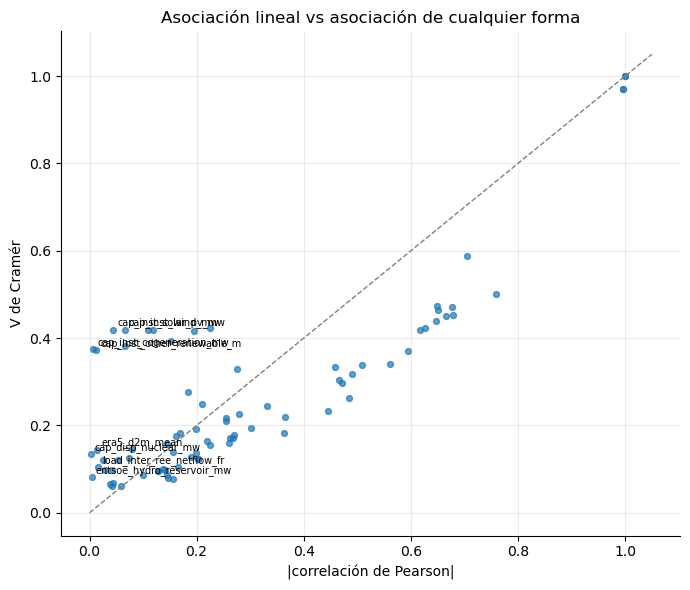

Los puntos MUY por encima de la diagonal son relaciones no lineales: Pearson las
infravalora y un modelo lineal las desaprovecharía.

Ordenadas por ratio Cramér/Pearson -- cuanto mayor, más no lineal es la relación:


,pearson_abs,cramer,ratio
variable,,,
cap_inst_cogeneration_mw,0.0063,0.3752,59.2741
cap_disp_nuclear_mw,0.0023,0.1337,57.8685
cap_inst_other_renewable_mw,0.0122,0.3722,30.4181
entsoe_hydro_reservoir_mw,0.0041,0.0819,19.7695
era5_d2m_mean,0.0147,0.1445,9.8389
cap_inst_solar_pv_mw,0.0437,0.4197,9.6032
cap_inst_wind_mw,0.0655,0.4197,6.4085
load_inter_ree_netflow_fr,0.0164,0.1044,6.3653
cap_inst_hydro_mw,0.0671,0.3827,5.7019


In [28]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(R["pearson_abs"], R["cramer"], s=18, alpha=0.7)
lim = max(R["pearson_abs"].max(), R["cramer"].max()) * 1.05
ax.plot([0, lim], [0, lim], color="grey", ls="--", lw=1)
for v, row in R.nlargest(8, "ratio").iterrows():
    ax.annotate(v[:26], (row["pearson_abs"], row["cramer"]), fontsize=7,
                xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("|correlación de Pearson|"); ax.set_ylabel("V de Cramér")
ax.set_title("Asociación lineal vs asociación de cualquier forma")
plt.tight_layout(); plt.show()

print("Los puntos MUY por encima de la diagonal son relaciones no lineales: Pearson las")
print("infravalora y un modelo lineal las desaprovecharía.\n")
print("Ordenadas por ratio Cramér/Pearson -- cuanto mayor, más no lineal es la relación:")
display(R.nlargest(12, "ratio")[["pearson_abs", "cramer", "ratio"]].round(4))

**Consecuencia.** Cada variable claramente por encima de la diagonal es una candidata a
transformación o a un modelo capaz de capturar no linealidades. Y el caso concreto que ya
conocemos —temperatura frente a demanda— sirve de control: si aparece ahí, la técnica funciona;
si no aparece, hay que revisar la discretización antes de fiarse del resto del ranking.

**Advertencia que la función original no lleva.** El V de Cramér es sensible al número de
tramos: con quintiles y 58.000 observaciones, casi cualquier variable sale significativa. Sirve
para **ordenar** candidatas, no para decidir cuáles entran. Y no dice nada sobre la frontera de
fuga: una variable con Cramér altísimo puede seguir siendo inutilizable en producción.

---
## C · Distribución del driver por tramo del target

**Qué hacen las funciones originales.** `boxplot_targetbinaria` y `hist_targetbinaria` comparan
la distribución de una variable continua entre los dos niveles de un target binario. Es la
figura que responde "¿esta variable separa las clases?".

**La adaptación necesaria.** Nuestro target es continuo, no binario. La traducción directa es
partirlo en tramos —quintiles, o los tramos con significado del precio— y comparar la
distribución del driver en cada uno. Responde a la misma pregunta: **¿esta variable separa las
horas caras de las baratas?**

Es más informativo que una correlación porque enseña la *forma* de la relación, incluidas las
no monótonas que el bloque B acaba de detectar.

In [29]:
TRAMOS = 5
d = df[[TARGET]].dropna()
cortes = sorted(set(d[TARGET].quantile(np.linspace(0, 1, TRAMOS + 1))))
etiquetas = [f"Q{i+1}" for i in range(len(cortes) - 1)]
df["_tramo"] = pd.cut(df[TARGET], bins=cortes, labels=etiquetas, include_lowest=True)

print(f"Tramos de '{TARGET}':")
display(df.groupby("_tramo", observed=True)[TARGET].agg(
    horas="size", mínimo="min", mediana="median", máximo="max").round(1))

TOP = R.nlargest(6, "cramer").index.tolist()
NO_LINEALES = R.nlargest(4, "ratio").index.tolist()
print(f"\nMayor V de Cramér: {TOP}")
print(f"Más no lineales (ratio): {NO_LINEALES}")

Tramos de 'spot_es_omie':


,horas,mínimo,mediana,máximo
_tramo,,,,
Q1,11658,-15.0,5.7,27.9
Q2,11661,27.9,40.0,56.0
Q3,11655,56.0,78.0,94.2
Q4,11657,94.3,110.5,133.7
Q5,11658,133.7,176.6,700.0



Mayor V de Cramér: ['spot_es_esios', 'spot_es_entsoe', 'spot_pt_omie', 'spot_pt_entsoe', 'spot_fr_entsoe', 'commodities_gas_mibgas']
Más no lineales (ratio): ['cap_inst_cogeneration_mw', 'cap_disp_nuclear_mw', 'cap_inst_other_renewable_mw', 'entsoe_hydro_reservoir_mw']


C:\Users\torgi\AppData\Local\Temp\ipykernel_50332\978027251.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos, labels=etiquetas, showfliers=False)
C:\Users\torgi\AppData\Local\Temp\ipykernel_50332\978027251.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos, labels=etiquetas, showfliers=False)
C:\Users\torgi\AppData\Local\Temp\ipykernel_50332\978027251.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos, labels=etiquetas, showfliers=False)
C:\Users\torgi\AppData\Local\Temp\ipykernel_50332\978027251.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxpl

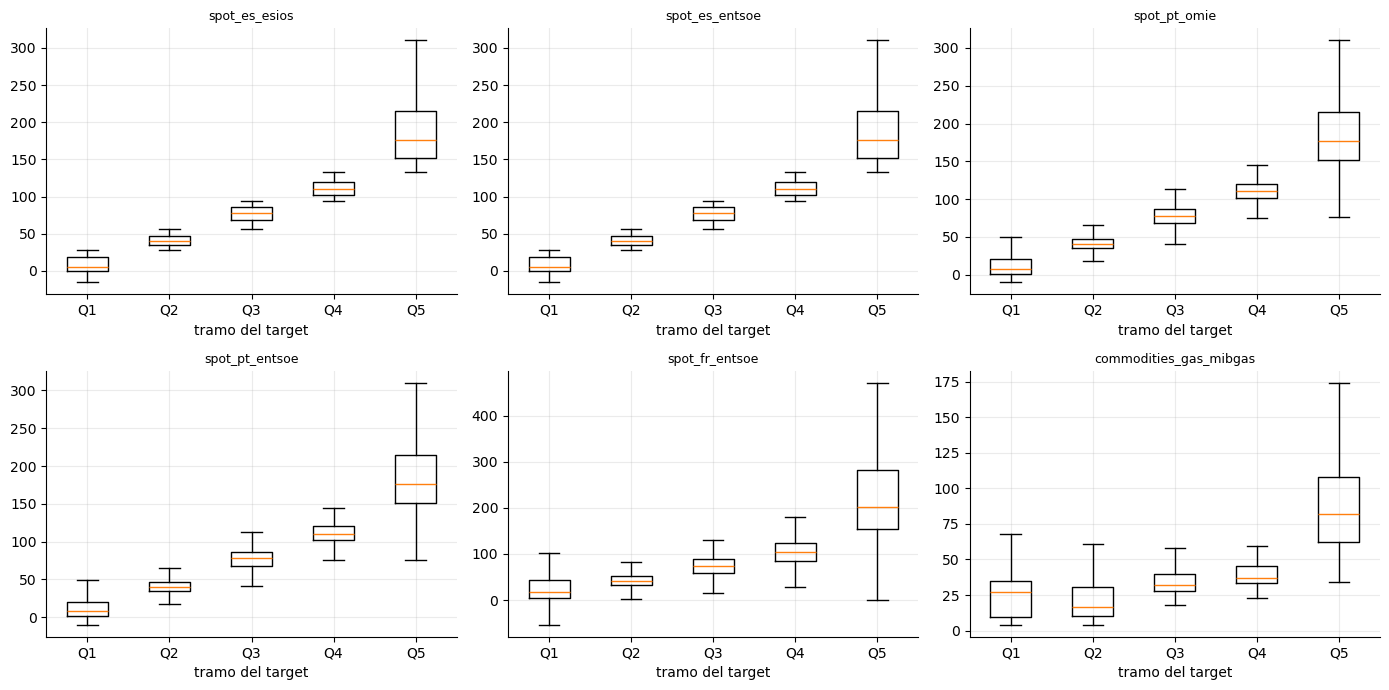

Una caja que sube o baja de forma monótona = relación direccional, que un modelo
lineal captura. Una en U o en campana = no lineal: ahí está el valor añadido de
mirar la forma en vez de quedarse con el coeficiente.


In [30]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, c in zip(axes.ravel(), TOP):
    datos = [df.loc[df["_tramo"] == e, c].dropna() for e in etiquetas]
    ax.boxplot(datos, labels=etiquetas, showfliers=False)
    ax.set_title(c[:34], fontsize=9)
    ax.set_xlabel("tramo del target")
plt.tight_layout(); plt.show()

print("Una caja que sube o baja de forma monótona = relación direccional, que un modelo")
print("lineal captura. Una en U o en campana = no lineal: ahí está el valor añadido de")
print("mirar la forma en vez de quedarse con el coeficiente.")

,spot_es_esios,spot_es_entsoe,spot_pt_omie,spot_pt_entsoe,spot_fr_entsoe,commodities_gas_mibgas
_tramo,,,,,,
Q1,9.7,9.7,11.7,11.7,29.8,26.6
Q2,40.8,40.8,41.0,41.0,46.3,21.3
Q3,77.0,77.0,77.0,77.0,77.0,34.9
Q4,111.6,111.6,111.6,111.6,119.9,41.9
Q5,190.2,190.2,190.1,190.1,238.8,89.2


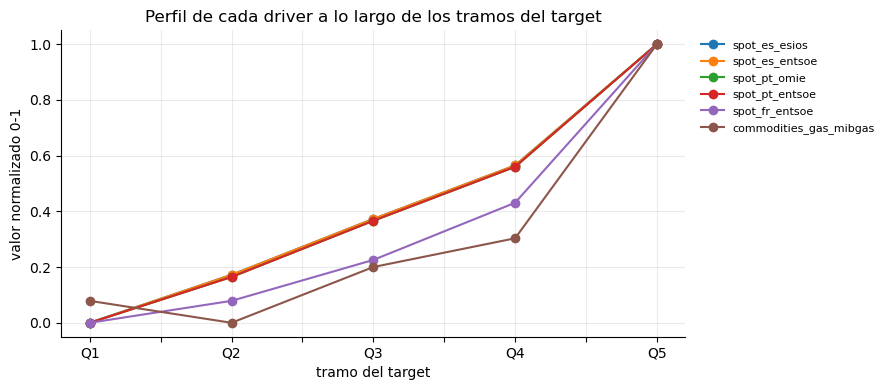

In [31]:
# La misma idea en tabla: media del driver por tramo, normalizada para poder comparar
# variables con escalas muy distintas.
perfil = df.groupby("_tramo", observed=True)[TOP].mean()
normal = (perfil - perfil.min()) / (perfil.max() - perfil.min())
display(perfil.round(1))

ax = normal.plot(marker="o", figsize=(9, 4))
ax.set_xlabel("tramo del target"); ax.set_ylabel("valor normalizado 0-1")
ax.set_title("Perfil de cada driver a lo largo de los tramos del target")
ax.legend(frameon=False, fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()

### C.1 · La vista inversa, que es donde aparecen las formas en U

**Por qué hace falta.** El gráfico anterior mira el driver *dentro* de cada tramo del target. Con
una relación en U eso sale **plano**: si el target es alto tanto con el driver bajo como con el
driver alto, su media dentro del tramo se queda en el centro y la forma desaparece.

La vista que sí la enseña es la contraria: **media del target por tramo del driver**. Comprobado
sobre una U simulada — en un sentido la señal se ve, en el otro se cancela. Es un detalle fácil
de pasar por alto y que haría descartar como irrelevante una variable que no lo es.

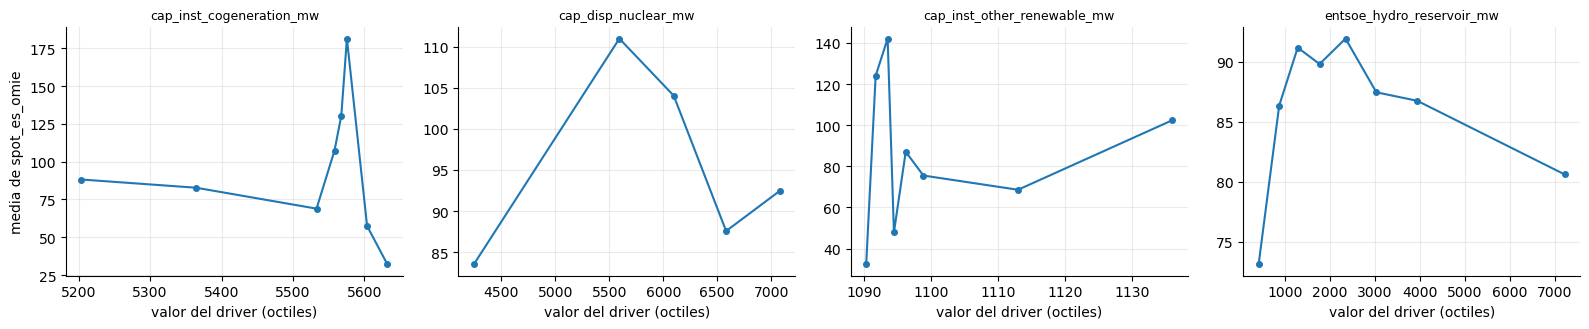

Una curva en U o en campana aquí confirma la no linealidad que el ratio Cramér/Pearson
señaló. Es la evidencia que justifica una transformación o un modelo no lineal, y la
figura que se lleva a la memoria -- no el coeficiente.


In [32]:
cols = NO_LINEALES if NO_LINEALES else TOP[:4]
fig, axes = plt.subplots(1, len(cols), figsize=(4 * len(cols), 3.4))
axes = np.atleast_1d(axes)
for ax, c in zip(axes, cols):
    d = df[[c, TARGET]].dropna()
    tramos_driver = pd.qcut(d[c], 8, duplicates="drop")
    perfil_inv = d.groupby(tramos_driver, observed=True)[TARGET].mean()
    ax.plot([iv.mid for iv in perfil_inv.index], perfil_inv.values, marker="o", ms=4)
    ax.set_title(c[:30], fontsize=9)
    ax.set_xlabel("valor del driver (octiles)")
    ax.set_ylabel(f"media de {TARGET[:18]}" if ax is axes[0] else "")
plt.tight_layout(); plt.show()

print("Una curva en U o en campana aquí confirma la no linealidad que el ratio Cramér/Pearson")
print("señaló. Es la evidencia que justifica una transformación o un modelo no lineal, y la")
print("figura que se lleva a la memoria -- no el coeficiente.")

---
## D · Las funciones que NO se pueden usar aquí

Éste es el bloque que más vale para la memoria. `FuncionesMineria.py` está diseñada para datos
**transversales** —una fila por individuo, sin orden entre ellas— y varias de sus funciones
producen resultados incorrectos sobre una serie temporal. Explicar por qué demuestra más
criterio que aplicarlas.

### D.1 · `atipicosAmissing` — convertiría el target en ruido

La función marca como atípico lo que supera 3 desviaciones (o 8 MAD si hay asimetría) **y**
queda fuera de 3×IQR, y lo reemplaza por `NaN`.

**Por qué aquí es destructivo.** En el precio eléctrico los valores extremos **son la señal**,
no contaminación: las horas de precio disparado son las que dominan el MAE y las de precio
negativo las que dan valor al arbitraje de la batería. Sustituirlas por `NaN` eliminaría
exactamente lo que hay que predecir.

Además, el criterio IQR ya se mostró inadecuado en el bloque C del notebook 02: con series que
cambian de régimen (carbón cerrado en 2021, baterías desde 2025, autoconsumo desde dic-2025)
marca miles de "atípicos" que son cambios estructurales reales.

**Qué se hace en su lugar.** Detectar lo físicamente imposible con criterio de dominio —una
demanda de 0 MW, no un percentil— como en el hallazgo C.1. Y los outliers estadísticos se
documentan, no se borran.

### D.2 · `validacion_cruzada_lm` y `validacion_cruzada_glm` — fuga temporal garantizada

Ambas usan `KFold` con partición aleatoria. Sobre una serie temporal, eso pone horas del futuro
en el conjunto de entrenamiento y horas del pasado en el de validación.

**Por qué es letal en este problema.** Con autocorrelación fuerte —y en el precio horario la hay,
el lag de 24 h es de los predictores más potentes— la validación cruzada aleatoria da métricas
optimistas que no se reproducen en producción. El modelo aprende a interpolar entre horas
vecinas, no a predecir.

**Qué se hace en su lugar.** Partición temporal estricta (train hasta una fecha, validación
después) o validación con ventana deslizante hacia adelante, que es lo que ya hace
`F11_baselines.ipynb`.

### D.3 · `ImputacionCuant` — media global sobre una serie con tendencia

Imputa con media, mediana o aleatorio de la distribución global.

**Por qué no aplica.** Imputar la solar de una hora nocturna con la media anual mete un valor
absurdo. Y en series con tendencia fuerte —la FV instalada pasa de 8.659 a 54.668 MW en el
período— la media global no representa ningún momento concreto.

**Qué se hace en su lugar.** Nada en el bronce, que por diseño no imputa. Y en silver,
interpolación temporal con criterio por variable: las de pico (`wind_gust10_mean`, `tp_mean`) no
se interpolan linealmente porque eso subestima los eventos extremos, que son los que mueven el
precio.

### D.4 · `Transf_Auto` y `mejorTransfCorr` — dragado de datos

Prueban siete transformaciones (log, exp, cuadrado, raíz…) y se quedan con la que maximiza la
correlación con el target.

**Por qué es peligroso.** Elegir la transformación mirando el target es una forma de
sobreajuste: la mejora encontrada incluye el ruido de la muestra. Sobre 58.000 observaciones y
decenas de variables, algo siempre "mejora".

**Cómo se usaría bien.** Ajustando la elección **sólo sobre el tramo de entrenamiento** y
verificándola después en validación. Y con una razón física detrás cuando exista: la relación
demanda-temperatura no necesita búsqueda automática, necesita grados-día, que es la
transformación que la ingeniería del sector ya usa.

### D.5 · `lm_stepwise` / `glm_stepwise` — selección con datos autocorrelados

La selección paso a paso por AIC/BIC asume observaciones independientes. Con autocorrelación, los
p-valores y los criterios de información están sesgados y el procedimiento tiende a meter
variables de más.

**Qué se hace en su lugar.** Selección con validación temporal, regularización, o importancia de
variables sobre el conjunto de validación. Y siempre después de filtrar por la frontera de fuga:
de nada sirve que el stepwise elija el precio francés de D+1.

### D.6 · Lo que sí transfiere sin cambios

`analizar_variables_categoricas`, `cuentaDistintos` y `frec_variables_num` son descriptivos
puros y funcionan igual. De hecho `cuentaDistintos` es equivalente al barrido de columnas
constantes del bloque A.4 del notebook 02, que confirmó D-04.

In [33]:
RESUMEN = pd.DataFrame([
    ("patron_perdidos",        "SÍ, con adaptación", "Agrupar por familia: con 40 columnas el mapa es ilegible."),
    ("Vcramer / graficoVcramer","SÍ, con adaptación", "Target continuo -> discretizar en quintiles. Ordena, no decide."),
    ("boxplot_targetbinaria",  "SÍ, con adaptación", "Target continuo -> tramos por cuantil en vez de dos clases."),
    ("cuentaDistintos",        "SÍ, directo",        "Equivale al barrido de columnas constantes (D-04)."),
    ("analizar_variables_categoricas", "SÍ, directo","Descriptivo puro."),
    ("atipicosAmissing",       "NO",                 "Los extremos del precio son la señal. Y el IQR falla con cambios de régimen."),
    ("validacion_cruzada_lm",  "NO",                 "KFold aleatorio sobre serie temporal = fuga del futuro al pasado."),
    ("ImputacionCuant/Cuali",  "NO",                 "Media global sobre serie con tendencia fuerte. Además el bronce no imputa."),
    ("Transf_Auto",            "SOLO EN TRAIN",      "Elegir transformación mirando el target es sobreajuste si se hace sobre todo."),
    ("lm_stepwise / glm_stepwise", "SOLO CON CAUTELA","AIC/BIC asumen independencia; con autocorrelación se sesgan."),
], columns=["función", "¿aplica?", "motivo"])
RESUMEN

,función,¿aplica?,motivo
0,patron_perdidos,"SÍ, con adaptación",Agrupar por familia: con 40 columnas el mapa e...
1,Vcramer / graficoVcramer,"SÍ, con adaptación",Target continuo -> discretizar en quintiles. O...
2,boxplot_targetbinaria,"SÍ, con adaptación",Target continuo -> tramos por cuantil en vez d...
3,cuentaDistintos,"SÍ, directo",Equivale al barrido de columnas constantes (D-...
4,analizar_variables_categoricas,"SÍ, directo",Descriptivo puro.
5,atipicosAmissing,NO,Los extremos del precio son la señal. Y el IQR...
6,validacion_cruzada_lm,NO,KFold aleatorio sobre serie temporal = fuga de...
7,ImputacionCuant/Cuali,NO,Media global sobre serie con tendencia fuerte....
8,Transf_Auto,SOLO EN TRAIN,Elegir transformación mirando el target es sob...
9,lm_stepwise / glm_stepwise,SOLO CON CAUTELA,AIC/BIC asumen independencia; con autocorrelac...


---
## Cierre

**Lo que este notebook añade a los anteriores:**

1. **La prueba formal de que los nulos de ERA5 y de las tablas diarias son estructurales**, en
   vez de la afirmación por inspección del bloque B del 02.
2. **Un ranking de drivers que no asume linealidad**, que es lo que el bloque G del 03 no puede
   dar. La diferencia entre ambos rankings señala dónde hay estructura que un modelo lineal
   desaprovecharía.
3. **La forma de la relación**, no sólo su intensidad, mediante la distribución del driver por
   tramo del target.

**Y una sección de memoria que no esperaba encontrar aquí:** el bloque D. Un TFM que aplica la
caja de herramientas de la asignatura sin cuestionarla es un trabajo de asignatura; uno que
explica cuáles no transfieren a series temporales y por qué, demuestra que se entiende la
diferencia entre el método y su dominio de validez.

**Pendiente:** rehacer los bloques B y C con `spot_price` como target real cuando entre al
bronce. Con la demanda como sustituta las técnicas quedan ilustradas, pero las conclusiones
sobre qué mueve el precio no son trasladables.